In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import jax
import jax.numpy as jnp

# Set device to CPU
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt


# Sequential Monte Carlo (SMC)

This notebook shows how to use the new `probjax.inference.smc_runner.SMC` interface with the SMC kernels.


In [3]:
from probjax.inference.mcmc import hmc
from probjax.inference.smc import smc
from probjax.inference.smc.path import GeometricPath
from probjax.inference.smc_runner import SMC


## 1D toy model
We define a simple prior and likelihood, then run tempered SMC.


In [4]:
key = jax.random.PRNGKey(0)
num_particles = 1024

def logprior_fn(x):
    return -0.5 * jnp.sum(x**2)

def loglikelihood_fn(x):
    return -0.5 * jnp.sum((x - 1.0) ** 2/.01)

particles = jax.random.normal(key, (num_particles, 1))


In [5]:
tempering_params = jnp.linspace(0.0, 1.0, 100)

kernel = smc(
    path=GeometricPath(),
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    mcmc_kernel=hmc,
    num_mcmc_steps=8,
    num_integration_steps=5,
)

state = kernel.init(
    particles,
    path=GeometricPath(),
    initial_path_param=tempering_params[0],
)
params = kernel.init_params(
    particles,
    path=GeometricPath(),
    mcmc_kernel=hmc,
    step_size=0.1,
    initial_path_param=tempering_params[0],
)


In [15]:
state

PathSMCState(particles=Array([[-0.20584214],
       [-0.78476578],
       [ 1.81608667],
       ...,
       [ 0.71559188],
       [-1.60519939],
       [-1.87234164]], dtype=float64), weights=Array([0.00097656, 0.00097656, 0.00097656, ..., 0.00097656, 0.00097656,
       0.00097656], dtype=float64), tempering_param=Array(0., dtype=float64))

In [14]:
params

{'step_size': Array([0.48580918], dtype=float64),
 'inverse_mass_matrix': Array([[1.]], dtype=float64)}

In [80]:
runner = SMC(kernel, verbose=True)
final_state, final_params = runner.run(key, state, tempering_params, params)


In [81]:
final_params

{'inverse_mass_matrix': Array([[1.]], dtype=float64),
 'step_size': Array([0.48580918], dtype=float64)}

Text(0.5, 1.0, 'SMC final particles')

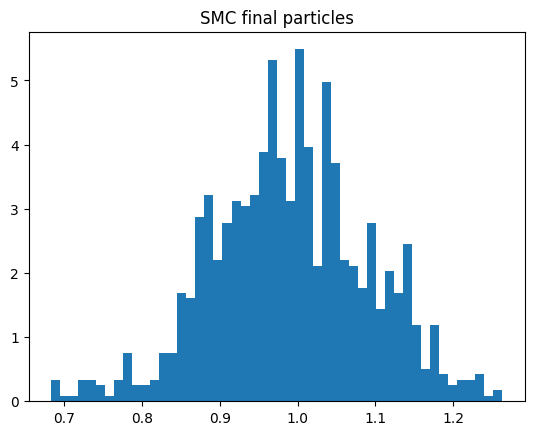

In [82]:
plt.hist(final_state.particles.flatten(), bins=50, density=True)
plt.title("SMC final particles")


## Sampling with history and tuning
The runner can also return the full particle and weight history and optionally tune MCMC parameters.


In [83]:
particles_hist, weights_hist, final_state, final_params = runner.sample(
    key,
    state,
    tempering_params,
    params,
    tune_params=True,
)


(array([0.07763123, 0.        , 0.07763123, 0.        , 0.        ,
        0.07763123, 0.15526245, 0.15526245, 0.07763123, 0.46578736,
        1.00920596, 0.31052491, 1.00920596, 0.62104982, 0.54341859,
        1.47499332, 2.01841191, 2.40656805, 1.55262455, 2.87235541,
        3.49340523, 3.415774  , 4.81313609, 2.94998664, 8.84995992,
        2.79472418, 4.81313609, 2.09604314, 4.2697175 , 4.89076732,
        1.16446841, 1.55262455, 2.48419927, 1.78551823, 4.03682382,
        1.707887  , 2.17367437, 1.00920596, 1.707887  , 0.46578736,
        1.39736209, 0.69868105, 0.38815614, 0.46578736, 0.23289368,
        0.15526245, 0.31052491, 0.23289368, 0.        , 0.23289368]),
 array([0.65069923, 0.66327874, 0.67585824, 0.68843775, 0.70101726,
        0.71359676, 0.72617627, 0.73875577, 0.75133528, 0.76391479,
        0.77649429, 0.7890738 , 0.8016533 , 0.81423281, 0.82681232,
        0.83939182, 0.85197133, 0.86455084, 0.87713034, 0.88970985,
        0.90228935, 0.91486886, 0.92744837, 0.

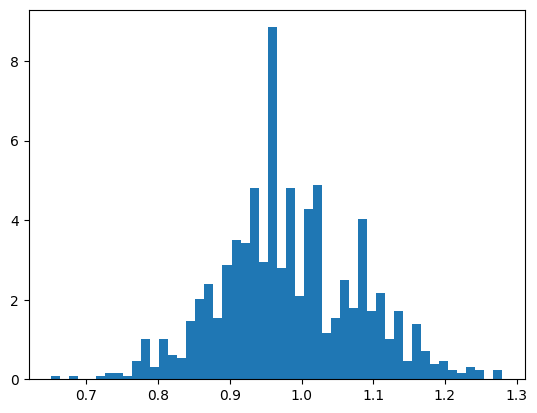

In [84]:
plt.hist(final_state.particles.flatten(), bins=50, density=True)